In [1]:
from pathlib import Path
# Setting directoris to GDrives
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [2]:
DATA_DIR = '/content/gdrive/MyDrive/diploma/sgnet'

In [3]:
import torch


def onehot(y, num_classes):
    y_onehot = torch.zeros(y.size(0), num_classes).to(y.device)
    if len(y.size()) == 1:
        y_onehot = y_onehot.scatter_(1, y.unsqueeze(-1), 1)
    elif len(y.size()) == 2:
        y_onehot = y_onehot.scatter_(1, y, 1)
    else:
        raise ValueError("[onehot]: y should be in shape [B], or [B, C]")
    return y_onehot


def thops_sum(tensor, dim=None, keepdim=False):
    if dim is None:
        # sum up all dim
        return torch.sum(tensor)
    else:
        if isinstance(dim, int):
            dim = [dim]
        dim = sorted(dim)
        for d in dim:
            tensor = tensor.sum(dim=d, keepdim=True)
        if not keepdim:
            for i, d in enumerate(dim):
                tensor.squeeze_(d-i)
        return tensor


def thops_mean(tensor, dim=None, keepdim=False):
    if dim is None:
        # mean all dim
        return torch.mean(tensor)
    else:
        if isinstance(dim, int):
            dim = [dim]
        dim = sorted(dim)
        for d in dim:
            tensor = tensor.mean(dim=d, keepdim=True)
        if not keepdim:
            for i, d in enumerate(dim):
                tensor.squeeze_(d-i)
        return tensor


def split_feature(tensor, type="split"):
    """
    type = ["split", "cross"]
    """
    C = tensor.size(1)
    if type == "split":
        return tensor[:, :C // 2, ...], tensor[:, C // 2:, ...]
    elif type == "cross":
        return tensor[:, 0::2, ...], tensor[:, 1::2, ...]


def cat_feature(tensor_a, tensor_b):
    return torch.cat((tensor_a, tensor_b), dim=1)


def thops_pixels(tensor):
    return int(tensor.size(2) * tensor.size(3))

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import scipy.linalg
# import thops


class InvertibleConv1x1(nn.Module):
    def __init__(self, num_channels, LU_decomposed=False):
        super().__init__()
        w_shape = [num_channels, num_channels]
        w_init = np.linalg.qr(np.random.randn(*w_shape))[0].astype(np.float32)
        if not LU_decomposed:
            # Sample a random orthogonal matrix:
            self.register_parameter("weight", nn.Parameter(torch.Tensor(w_init)))
        else:
            np_p, np_l, np_u = scipy.linalg.lu(w_init)
            np_s = np.diag(np_u)
            np_sign_s = np.sign(np_s)
            np_log_s = np.log(np.abs(np_s))
            np_u = np.triu(np_u, k=1)
            l_mask = np.tril(np.ones(w_shape, dtype=np.float32), -1)
            eye = np.eye(*w_shape, dtype=np.float32)

            self.register_buffer('p', torch.Tensor(np_p.astype(np.float32)))
            self.register_buffer('sign_s', torch.Tensor(np_sign_s.astype(np.float32)))
            self.l = nn.Parameter(torch.Tensor(np_l.astype(np.float32)))
            self.log_s = nn.Parameter(torch.Tensor(np_log_s.astype(np.float32)))
            self.u = nn.Parameter(torch.Tensor(np_u.astype(np.float32)))
            self.l_mask = torch.Tensor(l_mask)
            self.eye = torch.Tensor(eye)
        self.w_shape = w_shape
        self.LU = LU_decomposed

    def get_weight(self, input, reverse):
        w_shape = self.w_shape
        if not self.LU:
            pixels = pixels(input)
            dlogdet = torch.slogdet(self.weight)[1] * pixels
            if not reverse:
                weight = self.weight.view(w_shape[0], w_shape[1], 1, 1)
            else:
                weight = torch.inverse(self.weight.double()).float()\
                              .view(w_shape[0], w_shape[1], 1, 1)
            return weight, dlogdet
        else:
            self.p = self.p.to(input.device)
            self.sign_s = self.sign_s.to(input.device)
            self.l_mask = self.l_mask.to(input.device)
            self.eye = self.eye.to(input.device)
            l = self.l * self.l_mask + self.eye
            u = self.u * self.l_mask.transpose(0, 1).contiguous() + torch.diag(self.sign_s * torch.exp(self.log_s))
            dlogdet = thops_sum(self.log_s) * thops_pixels(input)
            if not reverse:
                w = torch.matmul(self.p, torch.matmul(l, u))
            else:
                l = torch.inverse(l.double()).float()
                u = torch.inverse(u.double()).float()
                w = torch.matmul(u, torch.matmul(l, self.p.inverse()))
            return w.view(w_shape[0], w_shape[1], 1, 1), dlogdet

    def forward(self, input, logdet=None, reverse=False):
        """
        log-det = log|abs(|W|)| * pixels
        """
        weight, dlogdet = self.get_weight(input, reverse)
        if not reverse:
            z = F.conv2d(input, weight)
            if logdet is not None:
                logdet = logdet + dlogdet
            return z, logdet
        else:
            z = F.conv2d(input, weight)
            if logdet is not None:
                logdet = logdet - dlogdet
            return z, logdet

In [5]:
import torch.nn as nn
import torch
from torchvision import transforms

# from models.modules import InvertibleConv1x1
import torch.nn.init as init
import torch.nn.functional as F

def default_conv(in_channels, out_channels, kernel_size, bias=True):
    return nn.Conv2d(
        in_channels, out_channels, kernel_size,
        padding=(kernel_size//2), bias=bias)


def projection_conv(in_channels, out_channels, scale, up=True):
    kernel_size, stride, padding = {
        2: (6, 2, 2),
        4: (8, 4, 2),
        8: (12, 8, 2),
        16: (20, 16, 2)
    }[scale]
    if up:
        conv_f = nn.ConvTranspose2d
    else:
        conv_f = nn.Conv2d

    return conv_f(
        in_channels, out_channels, kernel_size,
        stride=stride, padding=padding
    )


class ResBlock(nn.Module):
    def __init__(
        self, conv, n_feats, kernel_size,
        bias=True, bn=False, act=nn.ReLU(True), res_scale=1):

        super(ResBlock, self).__init__()
        m = []
        for i in range(2):
            m.append(conv(n_feats, n_feats, kernel_size, bias=bias))
            if bn:
                m.append(nn.BatchNorm2d(n_feats))
            if i == 0:
                m.append(act)

        self.body = nn.Sequential(*m)
        self.res_scale = res_scale

    def forward(self, x):
        res = self.body(x).mul(self.res_scale)
        res += x

        return res


## Residual Channel Attention Block (RCAB)
class RCAB(nn.Module):
    def __init__(
        self, conv, n_feat, kernel_size, reduction,
        bias=True, bn=False, act=nn.ReLU(True), res_scale=1):

        super(RCAB, self).__init__()
        modules_body = []
        for i in range(2):
            modules_body.append(conv(n_feat, n_feat, kernel_size, bias=bias))
            if bn: modules_body.append(nn.BatchNorm2d(n_feat))
            if i == 0: modules_body.append(act)
        modules_body.append(CALayer(n_feat, reduction))
        self.body = nn.Sequential(*modules_body)
        self.res_scale = res_scale

    def forward(self, x):
        res = self.body(x)
        #res = self.body(x).mul(self.res_scale)
        res += x
        return res

## Residual Group (RG)
class ResidualGroup(nn.Module):
    def __init__(self, conv, n_feat, kernel_size, reduction, n_resblocks):
        super(ResidualGroup, self).__init__()
        modules_body = []
        modules_body = [
            RCAB(
                conv, n_feat, kernel_size, reduction, bias=True, bn=False, act=nn.LeakyReLU(negative_slope=0.2, inplace=True), res_scale=1) \
            for _ in range(n_resblocks)]
        modules_body.append(conv(n_feat, n_feat, kernel_size))
        self.body = nn.Sequential(*modules_body)

    def forward(self, x):
        res = self.body(x)
        res += x
        return res


## Channel Attention (CA) Layer
class CALayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(CALayer, self).__init__()
        # global average pooling: feature --> point
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        # feature channel downscale and upscale --> channel weight
        self.conv_du = nn.Sequential(
                nn.Conv2d(channel, channel // reduction, 1, padding=0, bias=True),
                nn.ReLU(inplace=True),
                nn.Conv2d(channel // reduction, channel, 1, padding=0, bias=True),
                nn.Sigmoid()
        )

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv_du(y)
        return x * y

class DenseProjection(nn.Module):
    def __init__(self, in_channels, nr, scale, up=True, bottleneck=True):
        super(DenseProjection, self).__init__()
        self.up = up
        if bottleneck:
            self.bottleneck = nn.Sequential(*[
                nn.Conv2d(in_channels, nr, 1),
                nn.PReLU(nr)
            ])
            inter_channels = nr
        else:
            self.bottleneck = None
            inter_channels = in_channels

        self.conv_1 = nn.Sequential(*[
            projection_conv(inter_channels, nr, scale, up),
            nn.PReLU(nr)
        ])
        self.conv_2 = nn.Sequential(*[
            projection_conv(nr, inter_channels, scale, not up),
            nn.PReLU(inter_channels)
        ])
        self.conv_3 = nn.Sequential(*[
            projection_conv(inter_channels, nr, scale, up),
            nn.PReLU(nr)
        ])

    def forward(self, x):
        if self.bottleneck is not None:
            x = self.bottleneck(x)

        a_0 = self.conv_1(x)
        b_0 = self.conv_2(a_0)
        e = b_0.sub(x)
        a_1 = self.conv_3(e)

        out = a_0.add(a_1)
        return out


class InvBlock(nn.Module):
    def __init__(self, subnet_constructor, channel_num, channel_split_num, d = 1, clamp=0.8):
        super(InvBlock, self).__init__()
        # channel_num: 3
        # channel_split_num: 1

        self.split_len1 = channel_split_num  # 1
        self.split_len2 = channel_num - channel_split_num  # 2

        self.clamp = clamp

        self.F = subnet_constructor(self.split_len2, self.split_len1, d)
        self.G = subnet_constructor(self.split_len1, self.split_len2, d)
        self.H = subnet_constructor(self.split_len1, self.split_len2, d)

        in_channels = channel_num
        self.invconv = InvertibleConv1x1(in_channels, LU_decomposed=True)
        self.flow_permutation = lambda z, logdet, rev: self.invconv(z, logdet, rev)

    def forward(self, x, rev=False):
        # if not rev:
        # invert1x1conv
        x, logdet = self.flow_permutation(x, logdet=0, rev=False)

        # split to 1 channel and 2 channel.
        x1, x2 = (x.narrow(1, 0, self.split_len1), x.narrow(1, self.split_len1, self.split_len2))

        y1 = x1 + self.F(x2)  # 1 channel
        self.s = self.clamp * (torch.sigmoid(self.H(y1)) * 2 - 1)
        y2 = x2.mul(torch.exp(self.s)) + self.G(y1)  # 2 channel
        out = torch.cat((y1, y2), 1)

        return out


class UNetConvBlock(nn.Module):
    def __init__(self, in_size, out_size, d, relu_slope=0.1):
        super(UNetConvBlock, self).__init__()
        self.identity = nn.Conv2d(in_size, out_size, 1, 1, 0)

        self.conv_1 = nn.Conv2d(in_size, out_size, kernel_size=3, dilation=d, padding=d, bias=True)
        self.relu_1 = nn.LeakyReLU(relu_slope, inplace=False)
        self.conv_2 = nn.Conv2d(out_size, out_size, kernel_size=3, dilation=d, padding=d, bias=True)
        self.relu_2 = nn.LeakyReLU(relu_slope, inplace=False)

    def forward(self, x):
        out = self.relu_1(self.conv_1(x))
        out = self.relu_2(self.conv_2(out))
        out += self.identity(x)

        return out

def initialize_weights(net_l, scale=1):
    if not isinstance(net_l, list):
        net_l = [net_l]
    for net in net_l:
        for m in net.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, a=0, mode='fan_in')
                m.weight.data *= scale  # for residual block
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                init.kaiming_normal_(m.weight, a=0, mode='fan_in')
                m.weight.data *= scale
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias.data, 0.0)


def initialize_weights_xavier(net_l, scale=1):
    if not isinstance(net_l, list):
        net_l = [net_l]
    for net in net_l:
        for m in net.modules():
            if isinstance(m, nn.Conv2d):
                init.xavier_normal_(m.weight)
                m.weight.data *= scale  # for residual block
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                init.xavier_normal_(m.weight)
                m.weight.data *= scale
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias.data, 0.0)

def mean_channels(F):
    assert(F.dim() == 4)
    spatial_sum = F.sum(3, keepdim=True).sum(2, keepdim=True)
    return spatial_sum / (F.size(2) * F.size(3))


def stdv_channels(F):
    assert(F.dim() == 4)
    F_mean = mean_channels(F)
    F_variance = (F - F_mean).pow(2).sum(3, keepdim=True).sum(2, keepdim=True) / (F.size(2) * F.size(3))
    return F_variance.pow(0.5)


class DenseBlock(nn.Module):
    def __init__(self, channel_in, channel_out, d = 1, init='xavier', gc=8, bias=True):
        super(DenseBlock, self).__init__()
        self.conv1 = UNetConvBlock(channel_in, gc, d)
        self.conv2 = UNetConvBlock(gc, gc, d)
        self.conv3 = nn.Conv2d(channel_in + 2 * gc, channel_out, 3, 1, 1, bias=bias)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

        if init == 'xavier':
            initialize_weights_xavier([self.conv1, self.conv2, self.conv3], 0.1)
        else:
            initialize_weights([self.conv1, self.conv2, self.conv3], 0.1)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(x1))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))

        return x3

class DownBlock(nn.Module):
    def __init__(self, scale, in_channels=None, out_channels=None):
        super(DownBlock, self).__init__()
        down_m = []
        for _ in range(scale):
            down_m.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1, bias=False),
                    nn.PReLU()
                )
            )
        self.downModule = nn.Sequential(*down_m)

    def forward(self, x):
        x = self.downModule(x)
        return x


class UpBlock(nn.Module):
    def __init__(self, scale, in_channels=None, out_channels=None):
        super(UpBlock, self).__init__()
        up_m = []
        for _ in range(scale):
            up_m.append(
                nn.Sequential(
                    nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2, padding=0, bias=True),
                    nn.PReLU()
                )
            )
        self.downModule = nn.Sequential(*up_m)

    def forward(self, x):
        x = self.downModule(x)
        return x

class FreDiff(nn.Module):
    def __init__(self, channels,rgb_channels):
        super(FreDiff, self).__init__()

        self.fuse_c = nn.Sequential(nn.Conv2d(channels,channels,1,1,0),nn.LeakyReLU(0.1,inplace=False),
                                      nn.Conv2d(channels,channels,1,1,0))
        self.fuse_sub = nn.Sequential(nn.Conv2d(channels,channels,1,1,0),nn.LeakyReLU(0.1,inplace=False),
                                      nn.Conv2d(channels,channels,1,1,0))
        self.post = nn.Conv2d(2*channels,channels,1,1,0)
        self.pre_rgb = nn.Conv2d(rgb_channels,channels,1,1,0)
        self.pre_dep = nn.Conv2d(channels,channels,1,1,0)

        self.sig = nn.Sigmoid()

    def forward(self, dp, rgb):

        dp1 = self.pre_dep(dp)
        rgb1 = self.pre_rgb(rgb)

        fuse_c = self.fuse_c(dp1)

        fuse_sub = self.fuse_sub(torch.abs(rgb1 - dp1))
        cat_fuse = torch.cat([fuse_c,fuse_sub],1)

        return self.post(cat_fuse)

class SDB(nn.Module):
    def __init__(self, channels,rgb_channels):
        super(SDB, self).__init__()
        self.pre1 = nn.Conv2d(channels,channels,1,1,0)
        self.pre2 = nn.Conv2d(rgb_channels,rgb_channels,1,1,0)
        self.amp_fuse = FreDiff(channels,rgb_channels)
        self.pha_fuse = FreDiff(channels,rgb_channels)
        self.post = nn.Conv2d(channels,channels,1,1,0)

    def forward(self, dp, rgb):

        _, _, H, W = dp.shape
        dp = torch.fft.rfft2(self.pre1(dp)+1e-8, norm='backward')
        rgb = torch.fft.rfft2(self.pre2(rgb)+1e-8, norm='backward')
        dp_amp = torch.abs(dp)
        dp_pha = torch.angle(dp)
        rgb_amp = torch.abs(rgb)
        rgb_pha = torch.angle(rgb)
        amp_fuse = self.amp_fuse(dp_amp,rgb_amp)
        pha_fuse = self.pha_fuse(dp_pha,rgb_pha)

        real = amp_fuse * torch.cos(pha_fuse)+1e-8
        imag = amp_fuse * torch.sin(pha_fuse)+1e-8
        out = torch.complex(real, imag)+1e-8
        out = torch.abs(torch.fft.irfft2(out, s=(H, W), norm='backward'))

        return self.post(out)

class get_Fre(nn.Module):
    def __init__(self):
        super(get_Fre, self).__init__()

    def forward(self, dp):

        dp = torch.fft.rfft2(dp, norm='backward')
        dp_amp = torch.abs(dp)
        dp_pha = torch.angle(dp)

        return dp_amp, dp_pha

class SDM(nn.Module):
    def __init__(self, channels, rgb_channels,scale):
        super(SDM, self).__init__()
        self.rgbprocess = nn.Conv2d(rgb_channels, rgb_channels, 3, 1, 1)
        self.rgbpre = nn.Conv2d(rgb_channels, rgb_channels, 1, 1, 0)
        self.spa_process = nn.Sequential(InvBlock(DenseBlock, channels + rgb_channels, channels),
                                         nn.Conv2d(channels + rgb_channels, channels, 1, 1, 0))
        self.fre_process = SDB(channels, rgb_channels)
        self.spa_att = nn.Sequential(nn.Conv2d(channels, channels // 2, kernel_size=3, padding=1, bias=True),
                                     nn.LeakyReLU(0.1),
                                     nn.Conv2d(channels // 2, channels, kernel_size=3, padding=1, bias=True),
                                     nn.Sigmoid())
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.contrast = stdv_channels
        self.cha_att = nn.Sequential(nn.Conv2d(channels, channels // 2, kernel_size=1, padding=0, bias=True),
                                     nn.LeakyReLU(0.1),
                                     nn.Conv2d(channels // 2, channels, kernel_size=1, padding=0, bias=True),
                                     nn.Sigmoid())
        self.post = nn.Conv2d(channels, channels, 3, 1, 1)

        self.fuse_process = nn.Sequential(InvBlock(DenseBlock, 2*channels, channels),
                                         nn.Conv2d(2*channels, channels, 1, 1, 0))

        self.downBlock = DenseProjection(channels, channels, scale, up=False, bottleneck=False)
        self.upBlock = DenseProjection(channels, channels, scale, up=True, bottleneck=False)

    def forward(self, dp, rgb):  # , i

        dp = self.upBlock(dp)

        rgbpre = self.rgbprocess(rgb)
        rgb = self.rgbpre(rgbpre)
        spafuse = self.spa_process(torch.cat([dp, rgb], 1))
        frefuse = self.fre_process(dp, rgb)

        cat_f = torch.cat([spafuse, frefuse], 1)
        cat_f = self.fuse_process(cat_f)

        cha_res = self.cha_att(self.contrast(cat_f) + self.avgpool(cat_f)) * cat_f
        out = cha_res + dp

        out = self.downBlock(out)

        return out,rgbpre

class Get_gradient_nopadding_rgb(nn.Module):
    def __init__(self):
        super(Get_gradient_nopadding_rgb, self).__init__()
        kernel_v = [[0, -1, 0],
                    [0, 0, 0],
                    [0, 1, 0]]
        kernel_h = [[0, 0, 0],
                    [-1, 0, 1],
                    [0, 0, 0]]
        kernel_h = torch.FloatTensor(kernel_h).unsqueeze(0).unsqueeze(0)
        kernel_v = torch.FloatTensor(kernel_v).unsqueeze(0).unsqueeze(0)
        self.weight_h = nn.Parameter(data=kernel_h, requires_grad=False).cuda()
        self.weight_v = nn.Parameter(data=kernel_v, requires_grad=False).cuda()

    def forward(self, x):
        x0 = x[:, 0]
        x1 = x[:, 1]
        x2 = x[:, 2]
        x0_v = F.conv2d(x0.unsqueeze(1), self.weight_v, padding=1)
        x0_h = F.conv2d(x0.unsqueeze(1), self.weight_h, padding=1)

        x1_v = F.conv2d(x1.unsqueeze(1), self.weight_v, padding=1)
        x1_h = F.conv2d(x1.unsqueeze(1), self.weight_h, padding=1)

        x2_v = F.conv2d(x2.unsqueeze(1), self.weight_v, padding=1)
        x2_h = F.conv2d(x2.unsqueeze(1), self.weight_h, padding=1)

        x0 = torch.sqrt(torch.pow(x0_v, 2) + torch.pow(x0_h, 2) + 1e-6)
        x1 = torch.sqrt(torch.pow(x1_v, 2) + torch.pow(x1_h, 2) + 1e-6)
        x2 = torch.sqrt(torch.pow(x2_v, 2) + torch.pow(x2_h, 2) + 1e-6)

        x = torch.cat([x0, x1, x2], dim=1)
        return x

class Get_gradient_nopadding_d(nn.Module):
    def __init__(self):
        super(Get_gradient_nopadding_d, self).__init__()
        kernel_v = [[0, -1, 0],
                    [0, 0, 0],
                    [0, 1, 0]]
        kernel_h = [[0, 0, 0],
                    [-1, 0, 1],
                    [0, 0, 0]]
        kernel_h = torch.FloatTensor(kernel_h).unsqueeze(0).unsqueeze(0)
        kernel_v = torch.FloatTensor(kernel_v).unsqueeze(0).unsqueeze(0)
        self.weight_h = nn.Parameter(data=kernel_h, requires_grad=False).cuda()
        self.weight_v = nn.Parameter(data=kernel_v, requires_grad=False).cuda()

    def forward(self, x):
        x0 = x[:, 0]

        x0_v = F.conv2d(x0.unsqueeze(1), self.weight_v, padding=1)
        x0_h = F.conv2d(x0.unsqueeze(1), self.weight_h, padding=1)

        x0 = torch.sqrt(torch.pow(x0_v, 2) + torch.pow(x0_h, 2) + 1e-6)

        x = x0
        return x

class GCM(nn.Module):
    def __init__(self,n_feats,scale):
        super(GCM, self).__init__()
        self.grad_rgb = Get_gradient_nopadding_rgb()
        self.grad_d = Get_gradient_nopadding_d()
        self.upBlock = DenseProjection(1, 1, scale, up=True, bottleneck=False)
        self.downBlock = DenseProjection(n_feats, n_feats, scale, up=False, bottleneck=False)
        self.c_rgb = default_conv(3,n_feats,3)
        self.c_d = default_conv(1,n_feats,3)
        self.c_fuse = default_conv(n_feats,n_feats,3)

        self.rg_d = ResidualGroup(default_conv, n_feats, 3, reduction=16, n_resblocks=4)
        self.rb_rgbd = ResBlock(default_conv, n_feats, 3, bias=True, bn=False,
                                act=nn.LeakyReLU(negative_slope=0.2, inplace=True), res_scale=1)
        self.fuse_process = nn.Sequential(nn.Conv2d(2*n_feats, n_feats, 1, 1, 0),
                                          ResidualGroup(default_conv, n_feats, 3, reduction=8, n_resblocks=4),
                                          ResidualGroup(default_conv, n_feats, 3, reduction=8, n_resblocks=4))
        self.re_g = default_conv(n_feats,1,3)
        self.re_d = default_conv(n_feats,1,3)
        self.c_sab = default_conv(1,n_feats,3)
        self.sig = nn.Sigmoid()
        self.d1 = nn.Sequential(default_conv(1,n_feats,3),
                                ResidualGroup(default_conv, n_feats, 3, reduction=8, n_resblocks=8))

        self.CA = CALayer(n_feats,reduction=4)

        grad_conv = [
            default_conv(1, n_feats, kernel_size=3, bias=True),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            default_conv(n_feats, n_feats, kernel_size=3, bias=True),
        ]
        self.grad_conv = nn.Sequential(*grad_conv)
        self.grad_rg = nn.Sequential(ResidualGroup(default_conv, n_feats, 3, reduction=8, n_resblocks=4),
        ResidualGroup(default_conv, n_feats, 3, reduction=8, n_resblocks=4))

    def forward(self, depth,rgb):

        depth = self.upBlock(depth)

        grad_rgb = self.grad_rgb(rgb)
        grad_d = self.grad_d(depth)

        rgb1 = self.c_rgb(grad_rgb)
        d1 = self.c_d(grad_d)

        rgb2 = self.rb_rgbd(rgb1)
        d2 = self.rg_d(d1)

        cat1 = torch.cat([rgb2,d2],dim=1)

        inn1 = self.fuse_process(cat1)

        d3 = d1 + self.CA(inn1)

        grad_d2 = self.c_fuse(d3)

        out_re = self.re_g(grad_d2)

        d4 = self.d1(depth)

        grad_d3 = self.grad_conv(out_re) + d4

        grad_d4 = self.grad_rg(grad_d3)

        return out_re,self.downBlock(grad_d4)

In [6]:
# from models.common import *
import torch
import torch.nn as nn

class SGNet(nn.Module):
    def __init__(self, num_feats, kernel_size, scale):
        super(SGNet, self).__init__()
        self.conv_rgb1 = nn.Conv2d(in_channels=3, out_channels=num_feats,
                                   kernel_size=kernel_size, padding=1)
        self.rgb_rb2 = ResBlock(default_conv, num_feats, kernel_size, bias=True, bn=False,
                                act=nn.LeakyReLU(negative_slope=0.2, inplace=True), res_scale=1)
        self.rgb_rb3 = ResBlock(default_conv, num_feats, kernel_size, bias=True, bn=False,
                                act=nn.LeakyReLU(negative_slope=0.2, inplace=True), res_scale=1)
        self.rgb_rb4 = ResBlock(default_conv, num_feats, kernel_size, bias=True, bn=False,
                                act=nn.LeakyReLU(negative_slope=0.2, inplace=True), res_scale=1)

        self.conv_dp1 = nn.Conv2d(in_channels=1, out_channels=num_feats,
                                  kernel_size=kernel_size, padding=1)
        self.conv_dp2 = nn.Conv2d(in_channels=num_feats, out_channels=2*num_feats,
                                  kernel_size=kernel_size, padding=1)
        self.dp_rg1 = ResidualGroup(default_conv, num_feats, kernel_size, reduction=16, n_resblocks=6)
        self.dp_rg2 = ResidualGroup(default_conv, 2*num_feats, kernel_size, reduction=16, n_resblocks=6)
        self.dp_rg3 = ResidualGroup(default_conv, 2*num_feats, kernel_size, reduction=16, n_resblocks=6)
        self.dp_rg4 = ResidualGroup(default_conv, 3*num_feats, kernel_size, reduction=16, n_resblocks=6)

        self.bridge1 = SDM(channels=num_feats, rgb_channels=num_feats,scale=scale)
        self.bridge2 = SDM(channels=2*num_feats, rgb_channels=num_feats,scale=scale)
        self.bridge3 = SDM(channels=3*num_feats, rgb_channels=num_feats,scale=scale)

        self.c_de = default_conv(4*num_feats, 2*num_feats, 1)

        my_tail = [
            ResidualGroup(
                default_conv, 3*num_feats, kernel_size, reduction=16, n_resblocks=8),
            ResidualGroup(
                default_conv, 3*num_feats, kernel_size, reduction=16, n_resblocks=8),
            ResidualGroup(
                default_conv, 3*num_feats, kernel_size, reduction=16, n_resblocks=8)
        ]
        self.tail = nn.Sequential(*my_tail)

        self.upsampler = DenseProjection(3*num_feats, 3*num_feats, scale, up=True, bottleneck=False)
        last_conv = [
            default_conv(3*num_feats, num_feats, kernel_size=3, bias=True),
            nn.LeakyReLU(negative_slope=0.2, inplace=True),
            default_conv(num_feats, 1, kernel_size=3, bias=True)
        ]
        self.last_conv = nn.Sequential(*last_conv)
        self.bicubic = nn.Upsample(scale_factor=scale, mode='bicubic')

        self.c_rd = default_conv(8*num_feats, 3*num_feats, 1)
        self.c_grad = default_conv(2*num_feats, num_feats, 1)
        self.c_grad2 = default_conv(3*num_feats, 2*num_feats, 1)
        self.c_grad3 = default_conv(3*num_feats, 3*num_feats, 1)

        self.act = nn.LeakyReLU(negative_slope=0.2, inplace=True)

        self.gradNet = GCM(n_feats=num_feats,scale=scale)

    def forward(self, x):
        image, depth = x

        out_re, grad_d4 = self.gradNet(depth, image)

        dp_in = self.act(self.conv_dp1(depth))
        dp1 = self.dp_rg1(dp_in)

        cat10 = torch.cat([dp1, grad_d4], dim=1)
        dp1_ = self.c_grad(cat10)

        rgb1 = self.act(self.conv_rgb1(image))
        rgb2 = self.rgb_rb2(rgb1)

        ca1_in, r1 = self.bridge1(dp1_, rgb2)
        dp2 = self.dp_rg2(torch.cat([dp1, ca1_in + dp_in], 1))

        cat11 = torch.cat([dp2, grad_d4], dim=1)
        dp2_ = self.c_grad2(cat11)

        rgb3 = self.rgb_rb3(r1)
        ca2_in, r2 = self.bridge2(dp2_, rgb3)

        ca2_in_ = ca2_in + self.conv_dp2(dp_in)

        cat1_0 = torch.cat([dp2, ca2_in_], 1)

        dp3 = self.dp_rg3(self.c_de(cat1_0))
        rgb4 = self.rgb_rb4(r2)

        cat12 = torch.cat([dp3, grad_d4], dim=1)
        dp3_ = self.c_grad3(cat12)

        ca3_in, r3 = self.bridge3(dp3_, rgb4)

        cat1 = torch.cat([dp1, dp2, dp3, ca3_in], 1)

        dp4 = self.dp_rg4(self.c_rd(cat1))

        tail_in = self.upsampler(dp4)
        out = self.last_conv(self.tail(tail_in))

        out = out + self.bicubic(depth)

        return out, out_re

In [7]:
import random

def arugment(img,gt, hflip=True, rot=True):
    hflip = hflip and random.random() < 0.5
    vflip = rot and random.random() < 0.5

    if hflip:
        img = img[:, ::-1, :].copy()
        gt = gt[:, ::-1, :].copy()
    if vflip:
        img = img[::-1, :, :].copy()
        gt = gt[::-1, :, :].copy()

    return img, gt


def get_patch(img, gt, patch_size=16):
    th, tw = img.shape[:2]

    tp = round(patch_size)

    tx = random.randrange(0, (tw-tp))
    ty = random.randrange(0, (th-tp))

    return img[ty:ty + tp, tx:tx + tp, :], gt[ty:ty + tp, tx:tx + tp, :]

In [8]:
from torchvision import transforms
import numpy as np
import os
import random

from torch.utils.data import Dataset, DataLoader
from PIL import Image

def modcrop(image, modulo):
    h, w = image.shape[0], image.shape[1]
    h = h - h % modulo
    w = w - w % modulo

    return image[:h,:w]

class Middlebury_dataset(Dataset):
    """RGB-D-D Dataset."""

    def __init__(self, root_dir, scale=8, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images.
            scale (float): dataset scale
            transform (callable, optional): Optional transform to be applied on a sample.
        """

        self.transform = transform
        self.scale = scale

        self.GTs = []
        self.RGBs = []

        list_dir = os.listdir(root_dir)
        for name in list_dir:
            if name.find('output_color') > -1:
                self.RGBs.append('%s/%s' % (root_dir, name))
            elif name.find('output_depth') > -1:
                self.GTs.append('%s/%s' % (root_dir, name))
        self.RGBs.sort()
        self.GTs.sort()

    def __len__(self):
        return len(self.GTs)

    def __getitem__(self, idx):

        image = np.array(Image.open(self.RGBs[idx]))
        gt = np.array(Image.open(self.GTs[idx]))
        assert gt.shape[0] == image.shape[0] and gt.shape[1] == image.shape[1]
        s = self.scale
        image = modcrop(image, s)
        gt = modcrop(gt, s)

        h, w = gt.shape[0], gt.shape[1]
        s = self.scale

        lr = np.array(Image.fromarray(gt).resize((w//s,h//s),Image.BICUBIC)).astype(np.float32)
        gt = gt / 255.0
        image = image / 255.0
        lr = lr / 255.0


        if self.transform:
            image = self.transform(image).float()
            gt = self.transform(np.expand_dims(gt,2))
            lr = self.transform(np.expand_dims(lr,2)).float()

        # sample = {'guidance': image, 'lr': lr, 'gt': gt, 'max':maxx, 'min': minn}
        sample = {'guidance': image, 'lr': lr, 'gt': gt}
        return sample

In [9]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
# from data.common import get_patch,arugment

class NYU_v2_datset(Dataset):
    """NYUDataset."""

    def __init__(self, root_dir, scale=8, train=True, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images.
            scale (float): dataset scale
            train (bool): train or test
            transform (callable, optional): Optional transform to be applied on a sample.

        """
        self.root_dir = root_dir
        self.transform = transform
        self.scale = scale
        self.train = train

        if train:
            self.depths = np.load('%s/train_depth_split.npy'%root_dir)
            self.images = np.load('%s/train_images_split.npy'%root_dir)
        else:
            self.depths = np.load('%s/test_depth.npy'%root_dir)
            self.images = np.load('%s/test_images_v2.npy'%root_dir)

    def __len__(self):
        return self.depths.shape[0]

    def __getitem__(self, idx):
        depth = self.depths[idx]
        image = self.images[idx]
        if self.train:
            image, depth = get_patch(img=image, gt=np.expand_dims(depth,2), patch_size=256)
            image, depth = arugment(img=image, gt=depth)
        h, w = depth.shape[:2]
        s = self.scale
        lr = np.array(Image.fromarray(depth.squeeze()).resize((w//s,h//s), Image.BICUBIC))

        if self.transform:
            image = self.transform(image).float()
            depth = self.transform(depth).float()
            lr = self.transform(np.expand_dims(lr,2)).float()

        sample = {'guidance': image, 'lr': lr, 'gt': depth}

        return sample

In [10]:
import numpy as np
import os
import random

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# from data.common import arugment

def get_patch(img, lr, gt, scale, patch_size=16):
    th, tw = img.shape[:2]  ## HR image

    tp = round(patch_size)

    tx = random.randrange(0, (tw-tp))
    ty = random.randrange(0, (th-tp))
    lr_tx = tx // scale
    lr_ty = ty // scale
    lr_tp = tp // scale

    return img[ty:ty + tp, tx:tx + tp], lr[lr_ty:lr_ty + lr_tp, lr_tx:lr_tx + lr_tp], gt[ty:ty + tp, tx:tx + tp]

class RGBDD_Dataset(Dataset):
    """RGB-D-D Dataset."""

    def __init__(self, root_dir, scale=4, downsample='real', train=True, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images.
            scale (float): dataset scale
            downsample (str): kernel type of downsample, real mean use real LR and HR data
            train (bool): train or test
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        types = ['models', 'plants', 'portraits']


        self.root_dir = root_dir
        self.transform = transform
        self.scale = scale
        self.downsample = downsample
        self.train = train

        if train:
            if self.downsample == 'real':
                self.GTs = []
                self.LRs = []
                self.RGBs = []
                for type in types:
                    list_dir = os.listdir('%s/%s/%s_train'% (root_dir, type, type))
                    for n in list_dir:
                        self.RGBs.append('%s/%s/%s_train/%s/%s_RGB.jpg' % (root_dir, type, type, n, n))
                        self.GTs.append('%s/%s/%s_train/%s/%s_HR_gt.png' % (root_dir, type, type, n, n))
                        self.LRs.append('%s/%s/%s_train/%s/%s_LR_fill_depth.png' % (root_dir, type, type, n, n))
            else:
                self.GTs = []
                self.RGBs = []
                for type in types:
                    list_dir = os.listdir('%s/%s/%s_train'% (root_dir, type, type))
                    for n in list_dir:
                        self.RGBs.append('%s/%s/%s_train/%s/%s_RGB.jpg' % (root_dir, type, type, n, n))
                        self.GTs.append('%s/%s/%s_train/%s/%s_HR_gt.png' % (root_dir, type, type, n, n))

        else:
            if self.downsample == 'real':
                self.GTs = []
                self.LRs = []
                self.RGBs = []
                for type in types:
                    list_dir = os.listdir('%s/%s/%s_test'% (root_dir, type, type))
                    for n in list_dir:
                        self.RGBs.append('%s/%s/%s_test/%s/%s_RGB.jpg' % (root_dir, type, type, n, n))
                        self.GTs.append('%s/%s/%s_test/%s/%s_HR_gt.png' % (root_dir, type, type, n, n))
                        self.LRs.append('%s/%s/%s_test/%s/%s_LR_fill_depth.png' % (root_dir, type, type, n, n))
            else:
                self.GTs = []
                self.RGBs = []
                for type in types:
                    list_dir = os.listdir('%s/%s/%s_test'% (root_dir, type, type))
                    for n in list_dir:
                        self.RGBs.append('%s/%s/%s_test/%s/%s_RGB.jpg' % (root_dir, type, type, n, n))
                        self.GTs.append('%s/%s/%s_test/%s/%s_HR_gt.png' % (root_dir, type, type, n, n))

    def __len__(self):
        return len(self.GTs)

    def __getitem__(self, idx):
        if self.downsample == 'real':
            image =  np.array(Image.open(self.RGBs[idx]).convert("RGB")).astype(np.float32)
            gt = np.array(Image.open(self.GTs[idx])).astype(np.float32)

            h, w = gt.shape
            s = self.scale
            lr = np.array(Image.open(self.LRs[idx]).resize((w//s,h//s),Image.BICUBIC)).astype(np.float32)

        else:
            image = Image.open(self.RGBs[idx]).convert("RGB")
            image = np.array(image).astype(np.float32)
            gt = Image.open(self.GTs[idx])
            w, h = gt.size
            s = self.scale
            lr = np.array(gt.resize((w//s,h//s),Image.BICUBIC)).astype(np.float32)
            gt = np.array(gt).astype(np.float32)

        # normalization
        maxx = np.max(lr)
        minn = np.min(lr)
        lr=(lr-minn)/(maxx-minn)

        image_max = np.max(image)
        image_min = np.min(image)
        image = (image-image_min)/(image_max-image_min)

        if self.train:
            max_out = np.max(gt)
            min_out = np.min(gt)
            gt=(gt-min_out)/(max_out-min_out)
            image, lr, gt = get_patch(img=image, lr=np.expand_dims(lr, 2), gt=np.expand_dims(gt, 2), scale=self.scale, patch_size=256)

        if self.transform:
            image = self.transform(image).float()
            gt = self.transform(gt).float()
            lr = self.transform(lr).float()
        sample = {'guidance': image, 'lr': lr, 'gt': gt, 'max': maxx, 'min': minn}

        return sample

In [11]:
import torch

def calc_rmse(a, b, minmax):
    a = a[6:-6, 6:-6]
    b = b[6:-6, 6:-6]

    a = a*(minmax[0]-minmax[1]) + minmax[1]
    b = b*(minmax[0]-minmax[1]) + minmax[1]
    a = a * 100
    b = b * 100

    return torch.sqrt(torch.mean(torch.pow(a-b,2)))


def rgbdd_calc_rmse(gt, out, minmax):
    gt = gt[6:-6, 6:-6]
    out = out[6:-6, 6:-6]

    # gt = gt*(minmax[0]-minmax[1]) + minmax[1]
    out = out*(minmax[0]-minmax[1]) + minmax[1]
    gt = gt / 10.0
    out = out / 10.0

    return torch.sqrt(torch.mean(torch.pow(gt-out,2)))

def midd_calc_rmse(gt, out):
    gt = gt[6:-6, 6:-6]
    out = out[6:-6, 6:-6]
    gt = gt * 255.0
    out = out * 255.0

    return torch.sqrt(torch.mean(torch.pow(gt-out,2)))

In [14]:
import argparse
import os

# from utils import *
import numpy as np
import torchvision.transforms as transforms
from torchvision import utils
from torch import Tensor
from PIL import Image
from torchvision.utils import save_image, make_grid

from torch.utils.data import DataLoader
from torch.autograd import Variable

# from data.nyu_dataloader import *
# from data.rgbdd_dataloader import *
# from data.middlebury_dataloader import Middlebury_dataset

import cv2
import os

import torch.nn as nn
import torch.nn.functional as F
import torch

# parser = argparse.ArgumentParser()
# parser.add_argument('--scale', type=int, default=16, help='scale factor')
# parser.add_argument("--num_feats", type=int, default=40, help="channel number of the middle hidden layer")
# parser.add_argument("--root_dir", type=str, default='/datapath/RGB-D-D', help="root dir of dataset")
# parser.add_argument("--model_dir", type=str, default="/SGNet/ckpt/SGNet_X8_R.pth", help="path of model")
# parser.add_argument("--results_dir", type=str, default='SGNet/results', help="root dir of results")

# opt = parser.parse_args()
scale = 16
num_feats = 40
model_dir = DATA_DIR + '/model/SGNet_X16_R.pth'
# root_dir = DATA_DIR + '/Middlebury'
root_dir = DATA_DIR + '/nyu_data'
results_dir = DATA_DIR + '/res'

net = SGNet(num_feats=num_feats, kernel_size=3, scale=scale)
net.load_state_dict(torch.load(model_dir, map_location='cuda:0'))
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net.to(device)

data_transform = transforms.Compose([transforms.ToTensor()])

dataset_name = root_dir.split('/')[-1]
if dataset_name == 'nyu_data':
    dataset = NYU_v2_datset(root_dir=root_dir, scale=scale, transform=data_transform, train=False)
    test_minmax = np.load('%s/test_minmax.npy' % root_dir)
    rmse = np.zeros(449)
elif dataset_name == 'RGB-D-D':
    dataset = RGBDD_Dataset(root_dir=root_dir, scale=scale, downsample='sync', train=False, transform=data_transform)
    rmse = np.zeros(405)
elif dataset_name == 'Middlebury':
    dataset = Middlebury_dataset(root_dir=root_dir, scale=scale, transform=data_transform)
    rmse = np.zeros(30)
elif dataset_name == 'Lu':
    dataset = Middlebury_dataset(root_dir=root_dir, scale=scale, transform=data_transform)
    rmse = np.zeros(6)

dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=8)
data_num = len(dataloader)


with torch.no_grad():
    net.eval()
    if dataset_name == 'nyu_data':
        for idx, data in enumerate(dataloader):
            guidance, lr, gt = data['guidance'].to(device), data['lr'].to(device), data['gt'].to(device)
            out, out_grad = net((guidance, lr))
            minmax = test_minmax[:, idx]
            minmax = torch.from_numpy(minmax).cuda()
            rmse[idx] = calc_rmse(gt[0, 0], out[0, 0], minmax)

            path_output = '{}/output'.format(results_dir)
            os.makedirs(path_output, exist_ok=True)
            path_save_pred = '{}/{:010d}.png'.format(path_output, idx)

            # Save results  (Save the output depth map)
            pred = out[0,0] * (minmax[0] - minmax[1]) + minmax[1]
            pred = pred * 1000.0
            pred = pred.cpu().detach().numpy()
            pred = pred.astype(np.uint16)
            pred = Image.fromarray(pred)
            pred.save(path_save_pred)

            # visualization  (Visual depth map)
            pred = out[0, 0]
            pred = pred.cpu().detach().numpy()
            cv2.imwrite(path_save_pred, pred * 255.0)

            print(rmse[idx])
        print(rmse.mean())
    elif dataset_name == 'RGB-D-D':
        for idx, data in enumerate(dataloader):
            guidance, lr, gt, maxx, minn = data['guidance'].to(device), data['lr'].to(device), data['gt'].to(device), data[
                'max'].to(device), data['min'].to(device)
            out, out_grad = net((guidance, lr))
            minmax = [maxx, minn]
            rmse[idx] = rgbdd_calc_rmse(gt[0, 0], out[0, 0], minmax)

            path_output = '{}/output'.format(results_dir)
            os.makedirs(path_output, exist_ok=True)
            path_save_pred = '{}/{:010d}.png'.format(path_output, idx)

            # Save results  (Save the output depth map)
            pred = out[0, 0] * (maxx - minn) + minn
            pred = pred.cpu().detach().numpy()
            pred = pred.astype(np.uint16)
            pred = Image.fromarray(pred)
            pred.save(path_save_pred)

            # visualization  (Visual depth map)
            pred = out[0, 0]
            pred = pred.cpu().detach().numpy()
            cv2.imwrite(path_save_pred, pred * 255.0)
            print(rmse[idx])
        print(rmse.mean())
    elif (dataset_name == 'Middlebury') or (dataset_name == 'Lu'):
        for idx, data in enumerate(dataloader):
            guidance, lr, gt = data['guidance'].to(device), data['lr'].to(device), data['gt'].to(device)
            out, out_grad = net((guidance, lr))
            rmse[idx] = midd_calc_rmse(gt[0, 0], out[0, 0])

            path_output = '{}/output'.format(results_dir)
            os.makedirs(path_output, exist_ok=True)
            path_save_pred = '{}/{:010d}.png'.format(path_output, idx)

            # Save results  (Save the output depth map)
            pred = out[0,0] * 255.0
            pred = pred.cpu().detach().numpy()
            pred = pred.astype(np.uint16)
            pred = Image.fromarray(pred)
            pred.save(path_save_pred)

            # visualization  (Visual depth map)
            pred = out[0, 0]
            pred = pred.cpu().detach().numpy()
            cv2.imwrite(path_save_pred, pred * 255.0)

            print(rmse[idx])
        print(rmse.mean())

<ipython-input-14-0e5f6aca68d1>:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(model_dir, map_location='cuda:0'))
/usr/local/lib/python3.10

3.0643956661224365
4.522918701171875
4.095937252044678
7.378102779388428
2.846212387084961
2.349146604537964
2.7811758518218994
3.5392096042633057
3.3113837242126465
6.532183647155762
5.410909175872803
7.027411937713623
2.179663896560669
3.07189679145813
9.38969612121582
25.144908905029297
3.745755672454834
4.785515785217285
3.588639259338379
4.915924549102783
4.306520938873291
4.601138114929199
3.6982967853546143
2.7511019706726074
3.2799432277679443
6.599480152130127
1.8318313360214233
4.309587478637695
4.739627361297607
3.530031204223633
3.631690502166748
4.372346878051758
1.6964792013168335
3.686152696609497
1.8752834796905518
2.5256659984588623
3.138378143310547
2.719059944152832
2.8680295944213867
3.367220640182495
3.227701425552368
2.095916748046875
1.736013412475586
5.9717888832092285
2.345473051071167
2.577561616897583
1.4861565828323364
3.6714859008789062
3.32936692237854
4.286038875579834
5.718184471130371
2.4908015727996826
1.9366148710250854
6.344388008117676
2.33490085601

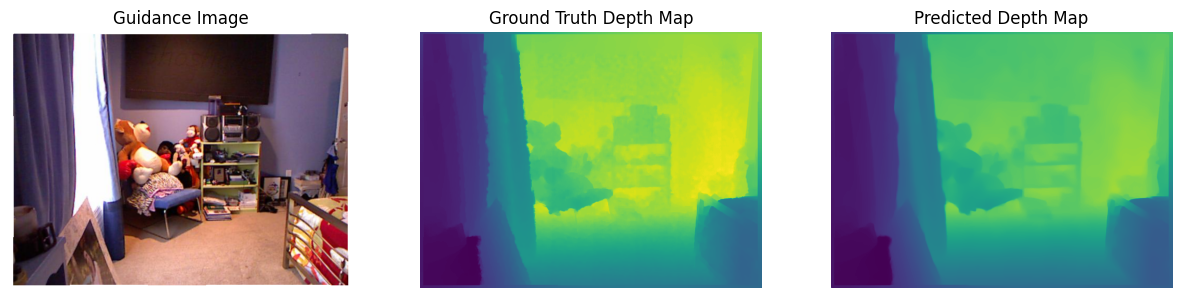

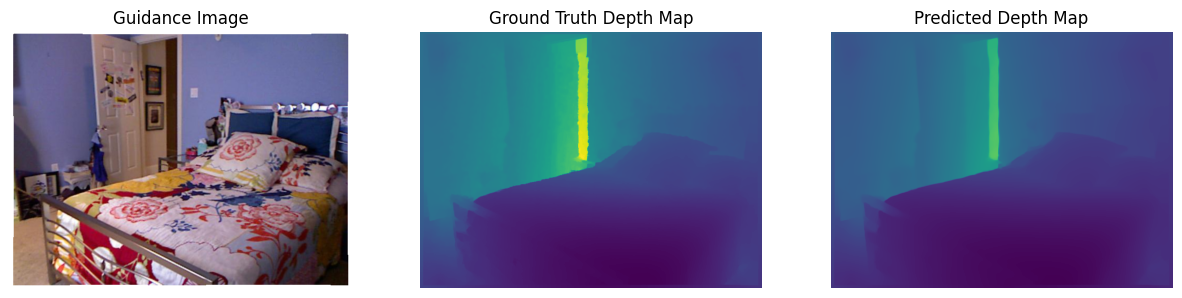

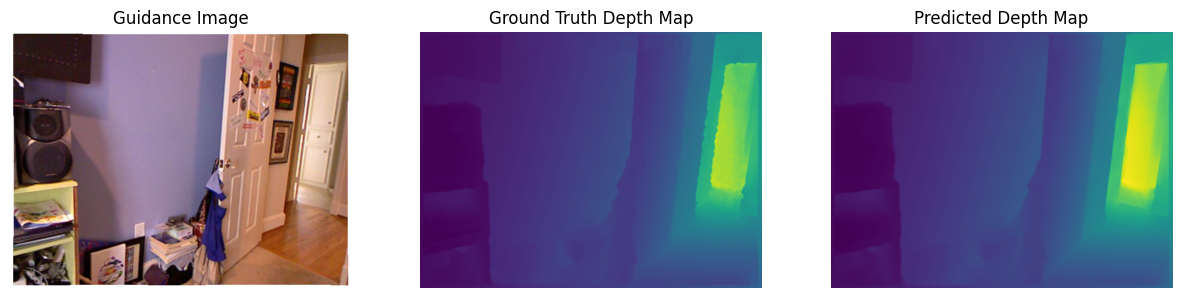

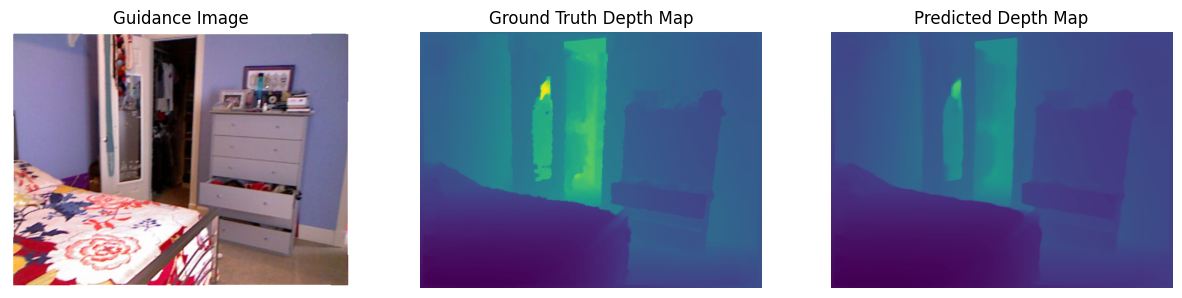

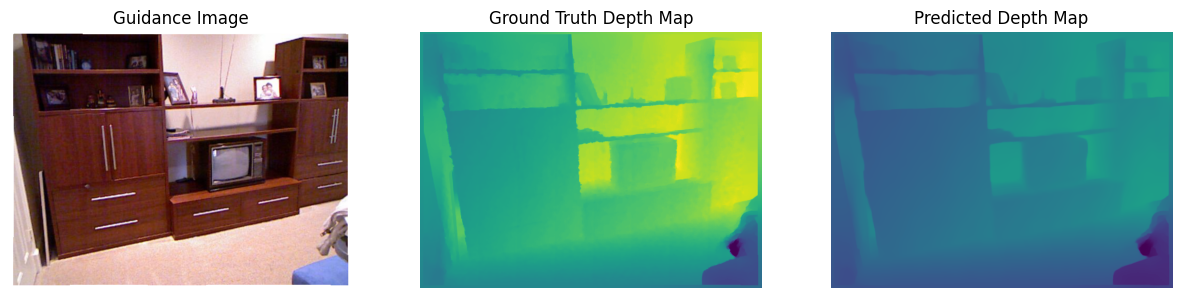

4.778245947674282


In [16]:
import matplotlib.pyplot as plt

visualization_count = 5
visualized = 0

with torch.no_grad():
    net.eval()
    if dataset_name == 'nyu_data':
        for idx, data in enumerate(dataloader):
            guidance, lr, gt = data['guidance'].to(device), data['lr'].to(device), data['gt'].to(device)
            out, out_grad = net((guidance, lr))
            minmax = test_minmax[:, idx]
            minmax = torch.from_numpy(minmax).cuda()
            rmse[idx] = calc_rmse(gt[0, 0], out[0, 0], minmax)

            pred = out[0, 0] * (minmax[0] - minmax[1]) + minmax[1]
            pred = pred * 1000.0
            pred_vis = pred.cpu().detach().numpy()

            # Visualize
            if visualized < visualization_count:
                fig, axs = plt.subplots(1, 3, figsize=(15, 5))

                # Original image
                axs[0].imshow(guidance[0].cpu().permute(1, 2, 0).numpy())
                axs[0].set_title("Guidance Image")
                axs[0].axis("off")

                # Ground truth depth map
                axs[1].imshow(gt[0, 0].cpu().numpy(), cmap="viridis")
                axs[1].set_title("Ground Truth Depth Map")
                axs[1].axis("off")

                # Predicted depth map
                axs[2].imshow(pred_vis, cmap="viridis")
                axs[2].set_title("Predicted Depth Map")
                axs[2].axis("off")

                plt.show()
                visualized += 1

            if visualized >= visualization_count:
                break

        print(rmse.mean())


<ipython-input-18-221abe79cfca>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(model_dir, map_location='cuda:0'))


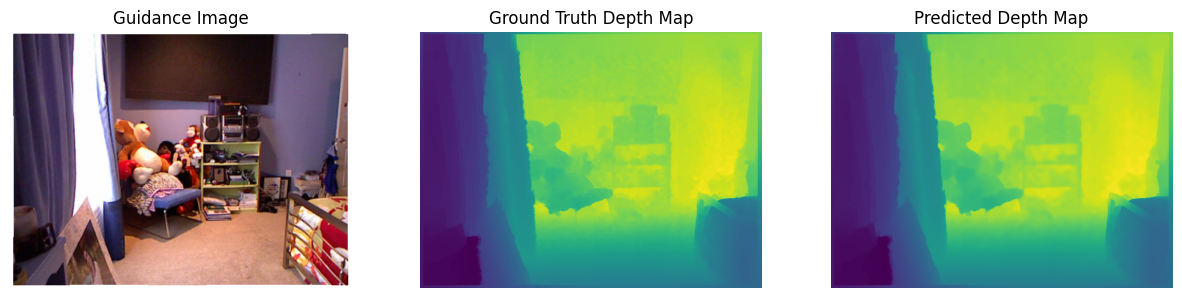

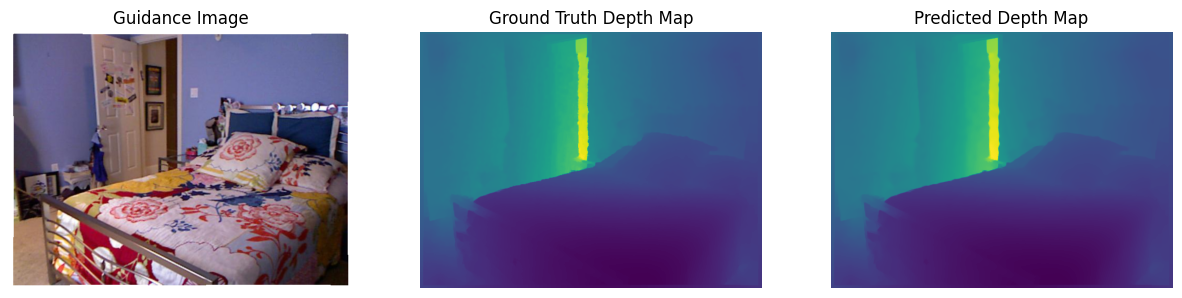

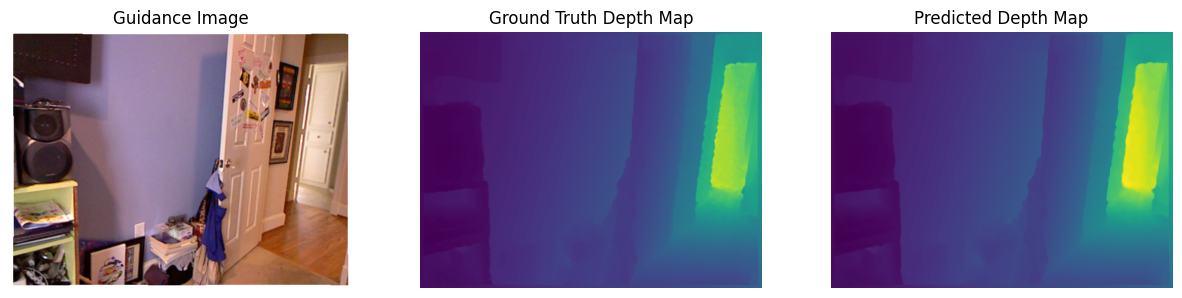

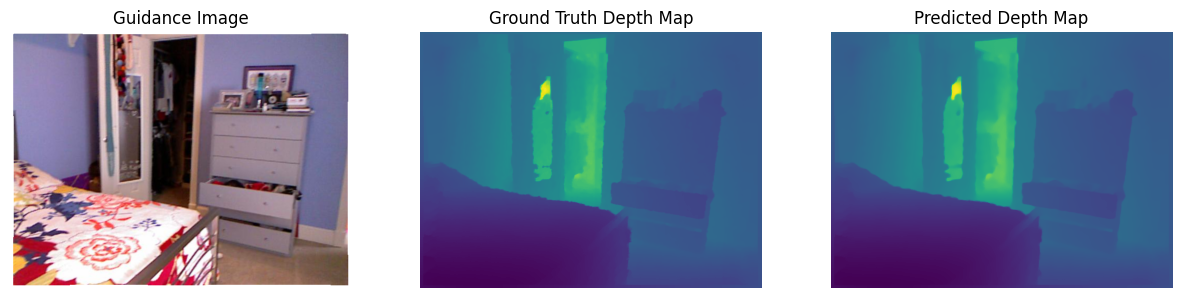

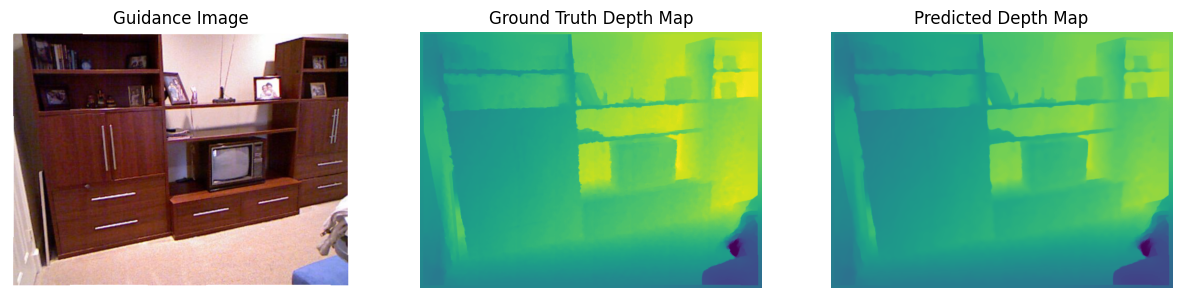

0.023621289395542613


In [18]:
scale = 8
num_feats = 40
model_dir = DATA_DIR + '/model/SGNet_X8_R.pth'

net = SGNet(num_feats=num_feats, kernel_size=3, scale=scale)
net.load_state_dict(torch.load(model_dir, map_location='cuda:0'))
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net.to(device)

data_transform = transforms.Compose([transforms.ToTensor()])

dataset_name = root_dir.split('/')[-1]
if dataset_name == 'nyu_data':
    dataset = NYU_v2_datset(root_dir=root_dir, scale=scale, transform=data_transform, train=False)
    test_minmax = np.load('%s/test_minmax.npy' % root_dir)
    rmse = np.zeros(449)

dataloader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=8)
data_num = len(dataloader)
import matplotlib.pyplot as plt

visualization_count = 5
visualized = 0

with torch.no_grad():
    net.eval()
    if dataset_name == 'nyu_data':
        for idx, data in enumerate(dataloader):
            guidance, lr, gt = data['guidance'].to(device), data['lr'].to(device), data['gt'].to(device)
            out, out_grad = net((guidance, lr))
            minmax = test_minmax[:, idx]
            minmax = torch.from_numpy(minmax).cuda()
            rmse[idx] = calc_rmse(gt[0, 0], out[0, 0], minmax)

            pred = out[0, 0] * (minmax[0] - minmax[1]) + minmax[1]
            pred = pred * 1000.0
            pred_vis = pred.cpu().detach().numpy()

            # Visualize
            if visualized < visualization_count:
                fig, axs = plt.subplots(1, 3, figsize=(15, 5))

                # Original image
                axs[0].imshow(guidance[0].cpu().permute(1, 2, 0).numpy())
                axs[0].set_title("Guidance Image")
                axs[0].axis("off")

                # Ground truth depth map
                axs[1].imshow(gt[0, 0].cpu().numpy(), cmap="viridis")
                axs[1].set_title("Ground Truth Depth Map")
                axs[1].axis("off")

                # Predicted depth map
                axs[2].imshow(pred_vis, cmap="viridis")
                axs[2].set_title("Predicted Depth Map")
                axs[2].axis("off")

                plt.show()
                visualized += 1

            if visualized >= visualization_count:
                break

        print(rmse.mean())

